# Recurrent Neural Networks

## Univariate Time Series Regression

This notebook demonstrates how to forecast the S&P 500 index using a Recurrent Neural Network.

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import pandas_datareader.data as web
from scipy.stats import spearmanr

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow import keras

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [4]:
sns.set_style("whitegrid")
np.random.seed(42)

In [5]:
results_path = Path("results", "univariate_time_series")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Get Data

We obtain data for 2010-2018 from the Federal Reserve Bank’s Data Service [FRED](https://fred.stlouisfed.org/) using the [pandas_datareader](https://pandas-datareader.readthedocs.io/) library introduced in [Chapter 2 on Market and Fundamental Data](../02_market_and_fundamental_data).

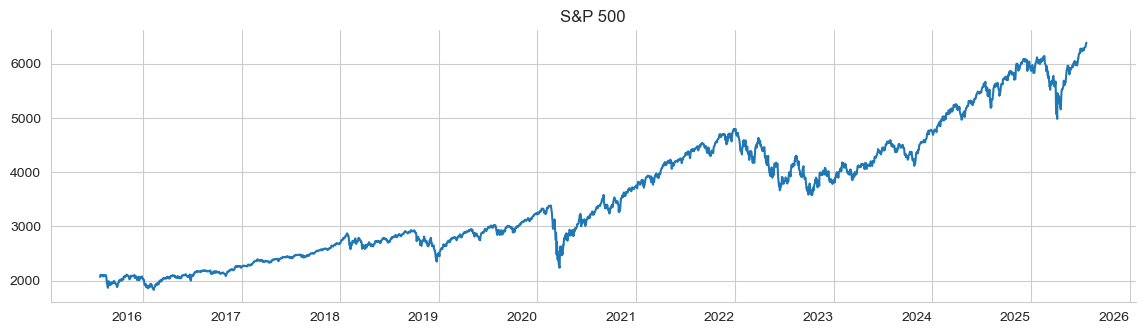

In [10]:
sp500 = web.DataReader("SP500", "fred", start=2015).dropna()
ax = sp500.plot(title="S&P 500", legend=False, figsize=(14, 4), rot=0)
ax.set_xlabel("")
sns.despine()

## Preprocessing

In [11]:
scaler = MinMaxScaler()

In [12]:
sp500_scaled = pd.Series(scaler.fit_transform(sp500).squeeze(), index=sp500.index)
sp500_scaled.describe()

count    2515.000000
mean        0.381269
std         0.259244
min         0.000000
25%         0.170116
50%         0.326016
75%         0.563183
max         1.000000
dtype: float64

## Generating recurrent sequences from our time series

Our time series is a sequence of numbers indexed by time:

$$x_{0},x_{1},x_{2},...,x_{T}$$

where $\{x_t\}$ is the numerical value in period $t$ and  $T$ is the total length of the series. 

To apply a RNN for regression of classification, we use a sliding window to construct a rolling set of input/output pairs for our model to learn from as animated below.

<img src="../assets/timeseries_windowing.gif" width=600 height=600/>

We will generate sequences of 63 trading days, approximately three months, and use a single LSTM layer with 20 hidden units to predict the index value one timestep ahead. 
The input to every LSTM layer must have three dimensions, namely:
- **Samples**: One sequence is one sample. A batch contains one or more samples.
- **Time Steps**: One time step is one point of observation in the sample.
- **Features**: One feature is one observation at a time step.

Our S&P 500 sample has 2,264 observations or time steps. We will create overlapping sequences using a window of 63 observations each.
For a simpler window of size T = 5, we obtain input-output pairs as shown in the following table:

$$\begin{array}{c|c}
\text{Input} & \text{Output}\\
\hline  {\langle x_1,x_2,x_3,x_4,x_5\rangle} & { x_6} \\
\ {\langle x_{2},x_{3},x_{4},x_{5},x_{6} \rangle } & {x_{7} } \\
  {\vdots} & {\vdots}\\
 { \langle x_{T-5},x_{T-4},x_{T-3},x_{T-2},x_{T-1} \rangle } &  {x_{T}}
\end{array}$$

Generally speaking, for window size S, the relationship takes the form 

$$x_t = f( x_{t-1}, x_{t-2}, ..., x_{t-S}) \quad\forall t=S, S+1, ..., T$$

Each of the $T-S$ lagged input sequence or vector is of length S with a corresponding scalar output.

We can use the function create_univariate_rnn_data() to stack sequences selected using a rolling windows:

In [13]:
def create_univariate_rnn_data(data, window_size):
    n = len(data)
    y = data[window_size:]
    data = data.values.reshape(-1, 1)  # make 2D
    X = np.hstack(
        tuple([data[i : n - j, :] for i, j in enumerate(range(window_size, 0, -1))])
    )
    return pd.DataFrame(X, index=y.index), y

We apply this function to the rescaled stock index for a window_size=63 to obtain a two-dimensional dataset of shape number of samples x number of timesteps:

In [14]:
window_size = 63

In [15]:
X, y = create_univariate_rnn_data(sp500_scaled, window_size=window_size)

In [16]:
X.head()

,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
DATE,,,,,,,,,,,,,,,,,,,,,
2015-10-23,0.052321,0.057938,0.061298,0.061311,0.060260,0.058988,0.057953,0.059383,0.055812,0.054499,...,0.040752,0.041315,0.038295,0.036223,0.042719,0.044748,0.044868,0.044235,0.041640,0.049003
2015-10-26,0.057938,0.061298,0.061311,0.060260,0.058988,0.057953,0.059383,0.055812,0.054499,0.060335,...,0.041315,0.038295,0.036223,0.042719,0.044748,0.044868,0.044235,0.041640,0.049003,0.053968
2015-10-27,0.061298,0.061311,0.060260,0.058988,0.057953,0.059383,0.055812,0.054499,0.060335,0.055924,...,0.038295,0.036223,0.042719,0.044748,0.044868,0.044235,0.041640,0.049003,0.053968,0.053097
2015-10-28,0.061311,0.060260,0.058988,0.057953,0.059383,0.055812,0.054499,0.060335,0.055924,0.056359,...,0.036223,0.042719,0.044748,0.044868,0.044235,0.041640,0.049003,0.053968,0.053097,0.051937
2015-10-29,0.060260,0.058988,0.057953,0.059383,0.055812,0.054499,0.060335,0.055924,0.056359,0.055775,...,0.042719,0.044748,0.044868,0.044235,0.041640,0.049003,0.053968,0.053097,0.051937,0.057302


In [17]:
y.head()

DATE
2015-10-23    0.053968
2015-10-26    0.053097
2015-10-27    0.051937
2015-10-28    0.057302
2015-10-29    0.057095
dtype: float64

In [18]:
X.shape

(2452, 63)

## Train-test split

To respect the time series nature of the data, we set aside the data at the end of the sample as hold-out or test set. More specifically, we'll use the data for 2018.

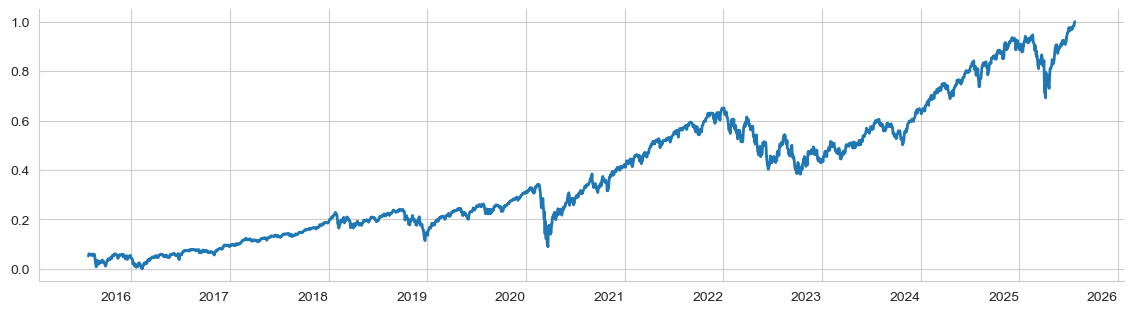

In [19]:
ax = sp500_scaled.plot(lw=2, figsize=(14, 4), rot=0)
ax.set_xlabel("")
sns.despine()

In [35]:
X_train = X[:"2023"].values.reshape(-1, window_size, 1)
y_train = y[:"2023"]

# keep the last year for testing
X_test = X["2024":].values.reshape(-1, window_size, 1)
y_test = y["2024":]

In [36]:
n_obs, window_size, n_features = X_train.shape

In [37]:
y_train.shape

(2060,)

## Keras LSTM Layer

Keras has several built-in RNN layers with various configuration options described in detail in the [documentation](https://keras.io/layers/recurrent/).

```
LSTM(units,
     activation='tanh',
     recurrent_activation='hard_sigmoid',
     use_bias=True,
     kernel_initializer='glorot_uniform',
     recurrent_initializer='orthogonal',
     bias_initializer='zeros',
     unit_forget_bias=True,
     kernel_regularizer=None,
     recurrent_regularizer=None,
     bias_regularizer=None,
     activity_regularizer=None,
     kernel_constraint=None,
     recurrent_constraint=None,
     bias_constraint=None,
     dropout=0.0,
     recurrent_dropout=0.0,
     implementation=1,
     return_sequences=False,
     return_state=False,
     go_backwards=False,
     stateful=False,
     unroll=False)
 ```

##  Define the Model Architecture

Having created input/output pairs out of our time series and cut this into training/testing sets, we can now begin setting up our RNN.  We use Keras to quickly build a two hidden layer RNN of the following specifications

- layer 1 uses an LSTM module with 20 hidden units (note here the input_shape = (window_size,1))
- layer 2 uses a fully connected module with one unit
- the 'mean_squared_error' loss should be used (remember: we are performing regression here)

This can be constructed using just a few lines - see e.g., the [general Keras documentation](https://keras.io/getting-started/sequential-model-guide/) and the [LSTM documentation in particular](https://keras.io/layers/recurrent/) for examples of how to quickly use Keras to build neural network models.  Make sure you are initializing your optimizer given the [keras-recommended approach for RNNs](https://keras.io/optimizers/) 

In [38]:
rnn = Sequential(
    [
        LSTM(units=10, input_shape=(window_size, n_features), name="LSTM"),
        Dense(1, name="Output"),
    ]
)

The summary shows that the model has 1,781 parameters:

In [39]:
rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

We train the model using the RMSProp optimizer recommended for RNN with default settings and compile the model with mean squared error for this regression problem:

In [40]:
optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08, decay=0.0)

In [41]:
rnn.compile(loss="mean_squared_error", optimizer=optimizer)

We define an EarlyStopping callback and train the model for up to 100 episodes. 

In [ ]:
rnn_path = (results_path / "rnn.keras").as_posix()
checkpointer = ModelCheckpoint(
    filepath=rnn_path, verbose=1, monitor="val_loss", save_best_only=True
)

In [43]:
early_stopping = EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

In [47]:
lstm_training = rnn.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=20,
    shuffle=True,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, checkpointer],
    verbose=1,
)

Epoch 1/150
 93/103 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1178
Epoch 1: val_loss improved from inf to 0.02120, saving model to results/univariate_time_series/rnn.h5


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1107 - val_loss: 0.0212
Epoch 2/150
 96/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 2: val_loss did not improve from 0.02120
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0014 - val_loss: 0.0278
Epoch 3/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.3860e-04
Epoch 3: val_loss did not improve from 0.02120
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.3848e-04 - val_loss: 0.0226
Epoch 4/150
 92/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.1856e-04
Epoch 4: val_loss improved from 0.02120 to 0.02028, saving model to results/univariate_time_series/rnn.h5


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.1479e-04 - val_loss: 0.0203
Epoch 5/150
100/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7702e-04
Epoch 5: val_loss improved from 0.02028 to 0.00865, saving model to results/univariate_time_series/rnn.h5


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7700e-04 - val_loss: 0.0087
Epoch 6/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.2781e-04
Epoch 6: val_loss did not improve from 0.00865
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.2719e-04 - val_loss: 0.0087
Epoch 7/150
 96/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0876e-04
Epoch 7: val_loss improved from 0.00865 to 0.00595, saving model to results/univariate_time_series/rnn.h5


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.0860e-04 - val_loss: 0.0060
Epoch 8/150
 98/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6749e-04
Epoch 8: val_loss did not improve from 0.00595
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.6525e-04 - val_loss: 0.0068
Epoch 9/150
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1274e-04
Epoch 9: val_loss improved from 0.00595 to 0.00258, saving model to results/univariate_time_series/rnn.h5


...

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0532e-04 - val_loss: 3.9610e-04
Epoch 22/150
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9144e-04
Epoch 22: val_loss did not improve from 0.00040
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9171e-04 - val_loss: 0.0019
Epoch 23/150
 92/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9551e-04
Epoch 23: val_loss did not improve from 0.00040
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9546e-04 - val_loss: 0.0018
Epoch 24/150
 93/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7206e-04
Epoch 24: val_loss did not improve from 0.00040
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7436e-04 - val_loss: 5.6334e-04
Epoch 25/150
 93/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0383e-04
Epoch 25: val_loss did not improve from 0.00040
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.0236e-04 - val_loss: 7.4338e-04
Epoch 26/150
102/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6645e-04
Epoch 26: val_loss improved from 0.0

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6666e-04 - val_loss: 3.7258e-04
Epoch 27/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8832e-04
Epoch 27: val_loss improved from 0.00037 to 0.00035, saving model to results/univariate_time_series/rnn.h5


103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8822e-04 - val_loss: 3.4785e-04
Epoch 28/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8147e-04
Epoch 28: val_loss did not improve from 0.00035
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8137e-04 - val_loss: 0.0016
Epoch 29/150
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8317e-04
Epoch 29: val_loss did not improve from 0.00035
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8285e-04 - val_loss: 7.1265e-04
Epoch 30/150
 93/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6842e-04
Epoch 30: val_loss did not improve from 0.00035
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6812e-04 - val_loss: 0.0012
Epoch 31/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5347e-04
Epoch 31: val_loss did not improve from 0.00035
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5356e-04 - val_loss: 9.1869e-04
Epoch 32/150
 97/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5632e-04
Epoch 32: val_loss did not improve f

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5850e-04 - val_loss: 3.2267e-04
Epoch 34/150
 95/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5482e-04
Epoch 34: val_loss did not improve from 0.00032
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5484e-04 - val_loss: 4.0178e-04
Epoch 35/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5809e-04
Epoch 35: val_loss did not improve from 0.00032
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5803e-04 - val_loss: 7.5986e-04
Epoch 36/150
 97/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6472e-04
Epoch 36: val_loss did not improve from 0.00032
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6380e-04 - val_loss: 8.1158e-04
Epoch 37/150
 98/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5559e-04
Epoch 37: val_loss did not improve from 0.00032
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5514e-04 - val_loss: 4.0681e-04
Epoch 38/150
 95/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4253e-04
Epoch 38: val_loss did not i

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4346e-04 - val_loss: 2.8238e-04
Epoch 43/150
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3954e-04
Epoch 43: val_loss did not improve from 0.00028
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3947e-04 - val_loss: 3.1903e-04
Epoch 44/150
 96/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5199e-04
Epoch 44: val_loss did not improve from 0.00028
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5057e-04 - val_loss: 3.7011e-04
Epoch 45/150
 97/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4192e-04
Epoch 45: val_loss did not improve from 0.00028
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4125e-04 - val_loss: 7.2383e-04
Epoch 46/150
 94/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2843e-04
Epoch 46: val_loss did not improve from 0.00028
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2859e-04 - val_loss: 6.4539e-04
Epoch 47/150
101/103 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1464e-04
Epoch 47: val_loss did not i

Training stops after 51 epochs; the `early_stopping` callback restores the weights for the best model (after 41 epochs)

## Evaluate model performance

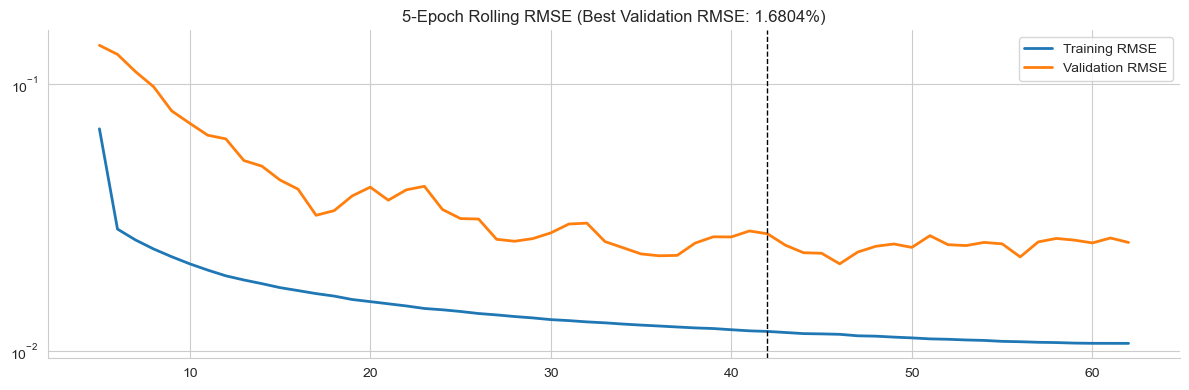

In [48]:
fig, ax = plt.subplots(figsize=(12, 4))

loss_history = pd.DataFrame(lstm_training.history).pow(0.5)
loss_history.index += 1
best_rmse = loss_history.val_loss.min()

best_epoch = loss_history.val_loss.idxmin()

title = f"5-Epoch Rolling RMSE (Best Validation RMSE: {best_rmse:.4%})"
loss_history.columns = ["Training RMSE", "Validation RMSE"]
loss_history.rolling(5).mean().plot(logy=True, lw=2, title=title, ax=ax)

ax.axvline(best_epoch, ls="--", lw=1, c="k")

sns.despine()
fig.tight_layout()
fig.savefig(results_path / "rnn_sp500_error", dpi=300);

In [55]:
train_rmse_scaled = np.sqrt(rnn.evaluate(X_train, y_train, verbose=0))
test_rmse_scaled = np.sqrt(rnn.evaluate(X_test, y_test, verbose=0))
print(f"Train RMSE: {train_rmse_scaled:.4f} | Test RMSE: {test_rmse_scaled:.4f}")

Train RMSE: 0.0123 | Test RMSE: 0.0168


In [56]:
train_predict_scaled = rnn.predict(X_train)
test_predict_scaled = rnn.predict(X_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [57]:
train_ic = spearmanr(y_train, train_predict_scaled)[0]
test_ic = spearmanr(y_test, test_predict_scaled)[0]
print(f"Train IC: {train_ic:.4f} | Test IC: {test_ic:.4f}")

Train IC: 0.9976 | Test IC: 0.9810


### Rescale predictions

In [58]:
train_predict = pd.Series(
    scaler.inverse_transform(train_predict_scaled).squeeze(), index=y_train.index
)
test_predict = pd.Series(
    scaler.inverse_transform(test_predict_scaled).squeeze(), index=y_test.index
)

In [59]:
y_train_rescaled = scaler.inverse_transform(y_train.to_frame()).squeeze()
y_test_rescaled = scaler.inverse_transform(y_test.to_frame()).squeeze()

In [60]:
train_rmse = np.sqrt(mean_squared_error(train_predict, y_train_rescaled))
test_rmse = np.sqrt(mean_squared_error(test_predict, y_test_rescaled))
f"Train RMSE: {train_rmse:.2f} | Test RMSE: {test_rmse:.2f}"

'Train RMSE: 56.25 | Test RMSE: 76.62'

In [62]:
sp500["Train Predictions"] = train_predict
sp500["Test Predictions"] = test_predict
sp500 = sp500.join(pd.concat([
    train_predict.to_frame("predictions")
    .assign(data="Train"),
    test_predict.to_frame("predictions").assign(data="Test")
    ]) 
)

### Plot Results

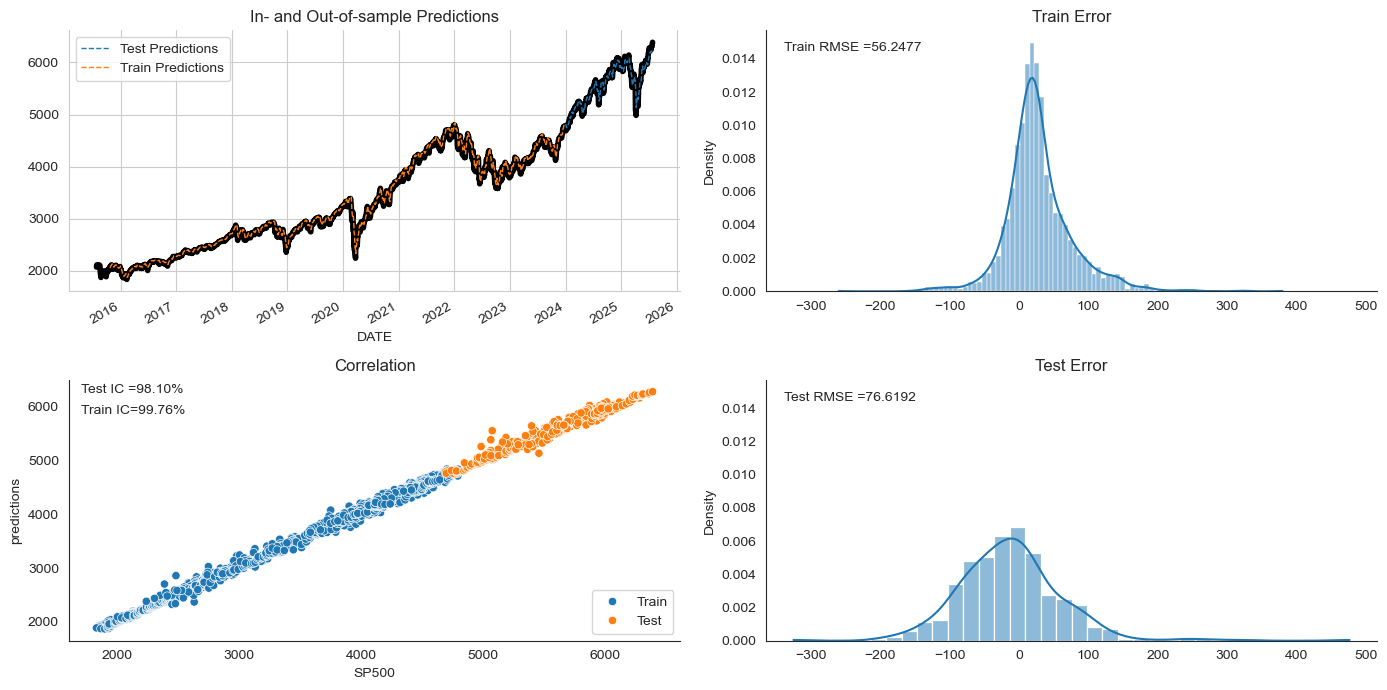

In [64]:
fig = plt.figure(figsize=(14, 7))
ax1 = plt.subplot(221)

sp500.loc["2015":, "SP500"].plot(lw=4, ax=ax1, c="k")
sp500.loc["2015":, ["Test Predictions", "Train Predictions"]].plot(
    lw=1, ax=ax1, ls="--"
)
ax1.set_title("In- and Out-of-sample Predictions")


with sns.axes_style("white"):
    ax3 = plt.subplot(223)
    sns.scatterplot(x="SP500", y="predictions", data=sp500, hue="data", ax=ax3)
    ax3.text(x=0.02, y=0.95, s=f"Test IC ={test_ic:.2%}", transform=ax3.transAxes)
    ax3.text(x=0.02, y=0.87, s=f"Train IC={train_ic:.2%}", transform=ax3.transAxes)
    ax3.set_title("Correlation")
    ax3.legend(loc="lower right")

    ax2 = plt.subplot(222)
    ax4 = plt.subplot(224, sharex=ax2, sharey=ax2)
    sns.histplot(train_predict.squeeze() - y_train_rescaled, ax=ax2, kde=True, stat='density')
    ax2.set_title("Train Error")
    ax2.text(x=0.03, y=0.92, s=f"Train RMSE ={train_rmse:.4f}", transform=ax2.transAxes)
    sns.histplot(test_predict.squeeze() - y_test_rescaled, ax=ax4, kde=True, stat='density')
    ax4.set_title("Test Error")
    ax4.text(x=0.03, y=0.92, s=f"Test RMSE ={test_rmse:.4f}", transform=ax4.transAxes)

sns.despine()
fig.tight_layout()
fig.savefig(results_path / "rnn_sp500_regression", dpi=300);